<a href="https://colab.research.google.com/github/everestso/everestso/blob/main/c126s26_NEON_1b.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import userdata
import os

# Retrieve secret from Colab Secrets
token = userdata.get("KAGGLE_API_TOKEN")

# Set environment variable for Kaggle
os.environ["KAGGLE_API_TOKEN"] = token

In [2]:
!pip -q uninstall -y kaggle kagglesdk
!pip -q install -U kagglesdk kaggle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.5/160.5 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.5/75.5 kB 3.3 MB/s eta 0:00:00


In [ ]:
!kaggle competitions files -c titanic

name                         size  creationDate                
---------------------  ----------  --------------------------  
gender_submission.csv        3258  2019-12-11 02:17:10.222000  
test.csv                    28629  2019-12-11 02:17:10.222000  
train.csv                   61194  2019-12-11 02:17:10.398000  


In [ ]:
# Search by keyword
!kaggle datasets list --search "imdb" --sort-by votes

# Filter by file type (e.g., csv)
!kaggle datasets list --file-type csv --sort-by votes

# Filter by size range (MB)
!kaggle datasets list --min-size 100 --max-size 500 --sort-by votes

# Filter by license (varies by dataset)
!kaggle datasets list --license "CC0-1.0" --sort-by votes

ref                                                             title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
--------------------------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
tmdb/tmdb-movie-metadata                                        TMDB 5000 Movie Dataset                                9317430  2017-09-28 01:09:12.897000         504887       4246  0.8235294        
rounakbanik/the-movies-dataset                                  The Movies Dataset                                   238862293  2017-11-10 02:40:38.583000         451716       3890  0.8235294        
lakshmi25npathi/imdb-dataset-of-50k-movie-reviews               IMDB Dataset of 50K Movie Reviews                     26962657  2019-03-09 06:32:21.130000         384854       1631  0.8235294        


In [ ]:
!kaggle competitions download -c titanic
!unzip -o titanic.zip

# Diamonds Dataset

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# ---------- Load ----------
!kaggle datasets download -d shivam2503/diamonds
!unzip -o diamonds.zip
df = pd.read_csv("/content/diamonds.csv")
print(df.head())

Dataset URL: https://www.kaggle.com/datasets/shivam2503/diamonds
License(s): unknown
diamonds.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  diamonds.zip
  inflating: diamonds.csv            
   Unnamed: 0  carat      cut color clarity  depth  table  price     x     y  \
0           1   0.23    Ideal     E     SI2   61.5   55.0    326  3.95  3.98   
1           2   0.21  Premium     E     SI1   59.8   61.0    326  3.89  3.84   
2           3   0.23     Good     E     VS1   56.9   65.0    327  4.05  4.07   
3           4   0.29  Premium     I     VS2   62.4   58.0    334  4.20  4.23   
4           5   0.31     Good     J     SI2   63.3   58.0    335  4.34  4.35   

      z  
0  2.43  
1  2.31  
2  2.31  
3  2.63  
4  2.75  


Top 'best + biggest' (intersection of top 1% quality AND top 1% carat):


,carat,cut,color,clarity,depth,table,price,x,y,z,quality_score


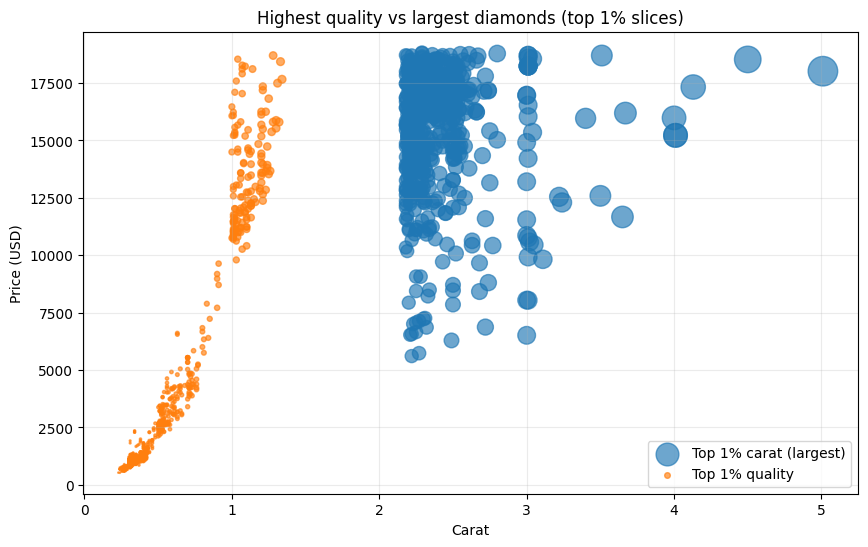

In [6]:
# ---------- Define "quality" ranking (best -> worst) ----------
cut_order = ["Fair", "Good", "Very Good", "Premium", "Ideal"]
color_order = ["J", "I", "H", "G", "F", "E", "D"]  # D best
clarity_order = ["I1", "SI2", "SI1", "VS2", "VS1", "VVS2", "VVS1", "IF"]  # IF best

cut_rank = {v: i for i, v in enumerate(cut_order)}
color_rank = {v: i for i, v in enumerate(color_order)}
clarity_rank = {v: i for i, v in enumerate(clarity_order)}

df["cut_rank"] = df["cut"].map(cut_rank)
df["color_rank"] = df["color"].map(color_rank)
df["clarity_rank"] = df["clarity"].map(clarity_rank)

# Higher is better; simple additive quality score
df["quality_score"] = df["cut_rank"] + df["color_rank"] + df["clarity_rank"]

# ---------- Pick "highest quality" and "largest" subsets ----------
top_quality = df[df["quality_score"] >= df["quality_score"].quantile(0.99)].copy()   # top 1% quality
top_largest = df[df["carat"] >= df["carat"].quantile(0.99)].copy()                  # top 1% carat (largest)

# Combine for a single viz; label each point
viz = pd.concat([
    top_quality.assign(group="Top 1% quality"),
    top_largest.assign(group="Top 1% carat (largest)")
], ignore_index=True).drop_duplicates()

# ---------- Quick table: "best + biggest" intersection ----------
best_and_big = df[(df["quality_score"] >= df["quality_score"].quantile(0.99)) &
                  (df["carat"] >= df["carat"].quantile(0.99))] \
                .sort_values(["carat","quality_score","price"], ascending=[False, False, False]) \
                .head(15)

print("Top 'best + biggest' (intersection of top 1% quality AND top 1% carat):")
display(best_and_big[["carat","cut","color","clarity","depth","table","price","x","y","z","quality_score"]])

# ---------- Visualization ----------
# Scatter: carat vs price. Marker size scales with carat. Color by group.
plt.figure(figsize=(10, 6))
for grp, sub in viz.groupby("group"):
    plt.scatter(sub["carat"], sub["price"],
                s=(sub["carat"]**2) * 18, alpha=0.65, label=grp)

plt.title("Highest quality vs largest diamonds (top 1% slices)")
plt.xlabel("Carat")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()